# Imports and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

## Random seed

In [4]:
randseed = 1229

## Load training data

In [3]:
dftrain = pd.read_csv('./test_proj/train_data.csv')

# Plots

## By cases, plotting straight-up

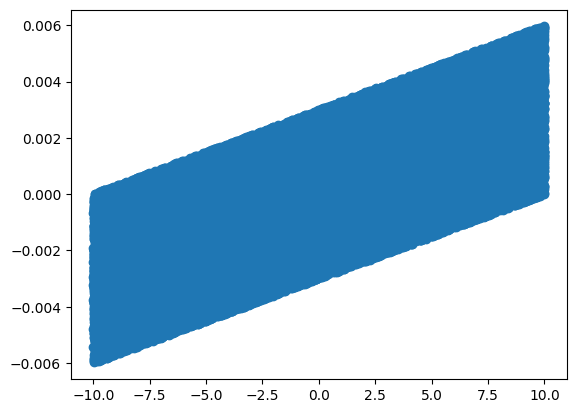

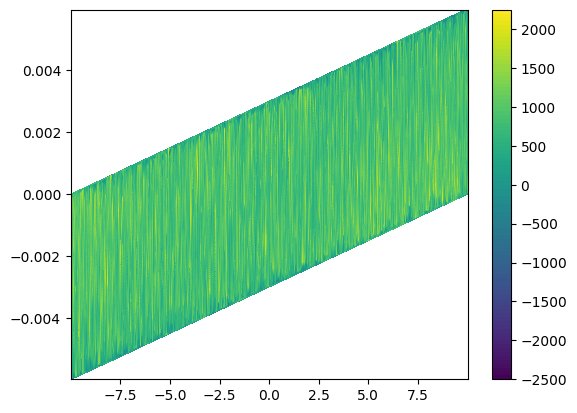

In [4]:
x3case = 1

plt.scatter(dftrain[dftrain['x3'] == x3case]['x1'], dftrain[dftrain['x3'] == x3case]['x2'])
plt.show()

plt.tricontourf(dftrain[dftrain['x3'] == x3case]['x1'], dftrain[dftrain['x3'] == x3case]['x2'], dftrain[dftrain['x3'] == x3case]['y'], levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

## Case $x_3 = 1$ transformed into square

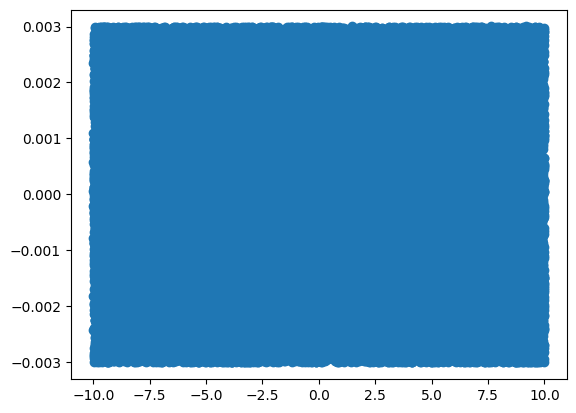

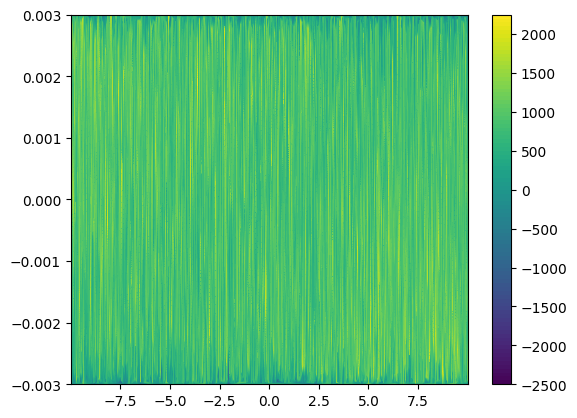

In [5]:
plt.scatter(dftrain[dftrain['x3'] == 1]['x1'], dftrain[dftrain['x3'] == 1]['x2'] - .0003 * dftrain[dftrain['x3'] == 1]['x1'])
plt.show()

plt.tricontourf(dftrain[dftrain['x3'] == 1]['x1'], dftrain[dftrain['x3'] == 1]['x2'] - 0.0003 * dftrain[dftrain['x3'] == 1]['x1'], dftrain[dftrain['x3'] == 1]['y'], levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

## PCA (not that useful I think)

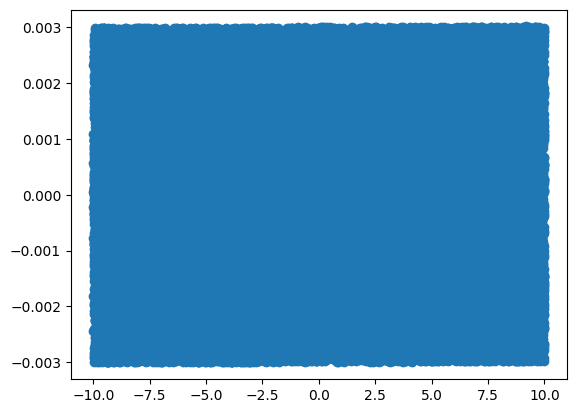

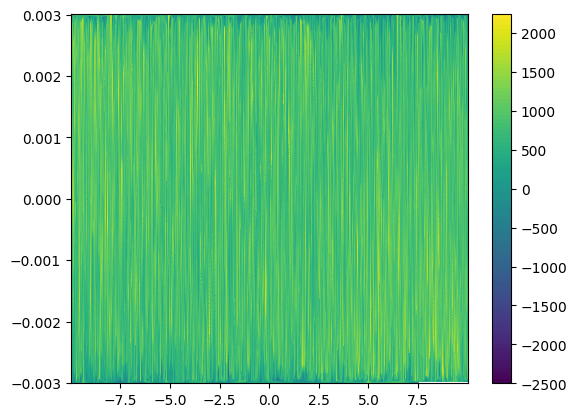

In [6]:
x3case = 1

x1x2 = dftrain[dftrain['x3'] == x3case][['x1','x2']]
pca = PCA(n_components = 2)
pca.fit(x1x2)
newx1x2 = pca.transform(x1x2)
plt.scatter(newx1x2[:, 0], newx1x2[:, 1])
plt.show()

plt.tricontourf(newx1x2[:, 0], newx1x2[:, 1], dftrain[dftrain['x3'] == x3case]['y'], levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

## Nearest neighbor type thing

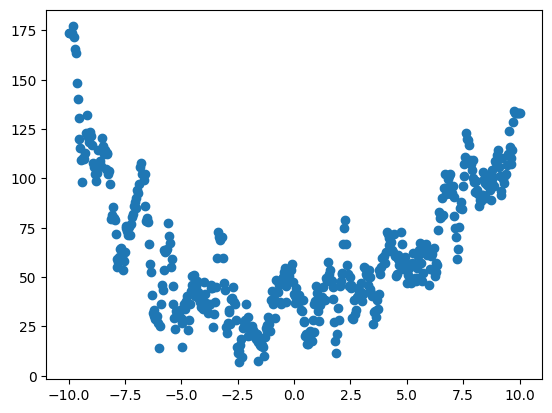

In [7]:
x3case = 0
nncnt = 1000

curx = dftrain[dftrain['x3'] == x3case]['x1']
cury = dftrain[dftrain['x3'] == x3case]['y']

knn = KNeighborsRegressor(n_neighbors = nncnt)
knn.fit(curx.to_numpy().reshape(-1, 1), cury)

newx = np.linspace(-10, 10, 500)
newy = knn.predict(newx.reshape(-1, 1))

plt.scatter(newx, newy)
plt.show()

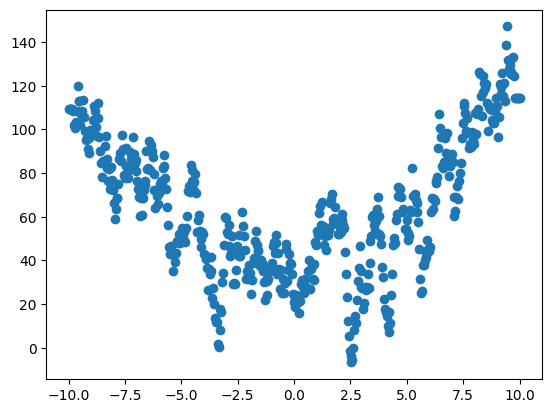

In [8]:
nncnt = 1000

curx = 10/.003 * dftrain[dftrain['x3'] == 0]['x2']
cury = dftrain[dftrain['x3'] == 0]['y']

knn = KNeighborsRegressor(n_neighbors = nncnt)
knn.fit(curx.to_numpy().reshape(-1, 1), cury)

newx = np.linspace(-10, 10, 500)
newy = knn.predict(newx.reshape(-1, 1))

plt.scatter(newx, newy)
plt.show()

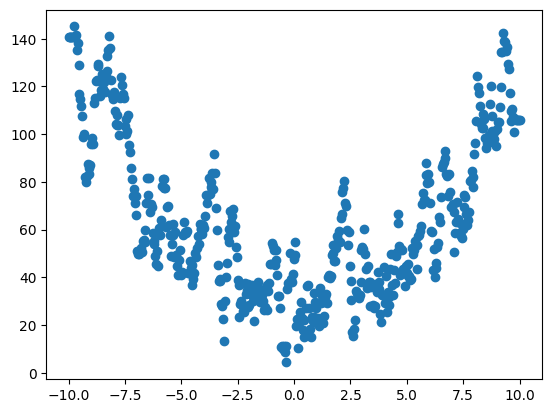

In [9]:
nncnt = 1000

curx = 10/.003 * dftrain[dftrain['x3'] == 1]['x2'] - dftrain[dftrain['x3'] == 1]['x1']
cury = dftrain[dftrain['x3'] == 1]['y']

knn = KNeighborsRegressor(n_neighbors = nncnt)
knn.fit(curx.to_numpy().reshape(-1, 1), cury)

newx = np.linspace(-10, 10, 500)
newy = knn.predict(newx.reshape(-1, 1))

plt.scatter(newx, newy)
plt.show()

# Linear regression with 80-20 validation set (BAD BECAUSE FITTING NOISE)

In [10]:
def getmodel(deg, lam):
    model = make_pipeline(
        PolynomialFeatures(degree = deg, include_bias = False),
        Ridge(alpha = lam)
    )
    return model

Order 1: eval = 253793.1251006444 lam = 10000.0
Order 2: eval = 248399.35782583468 lam = 100.0
Order 3: eval = 248270.08655540427 lam = 100.0
Order 4: eval = 248348.4676310764 lam = 100.0
Order 5: eval = 248353.211079485 lam = 100.0
Order 6: eval = 248350.97924618065 lam = 100.0
Order 7: eval = 248364.1876642745 lam = 100.0
Order 8: eval = 248351.8373089947 lam = 100.0
Order 9: eval = 248365.13750019518 lam = 100.0
Order 10: eval = 248364.74555792494 lam = 100.0

Best (eval = 248270.08655540427): deg = 3 lam = 100.0


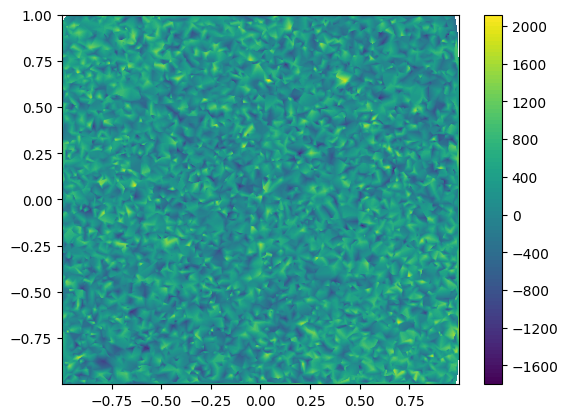

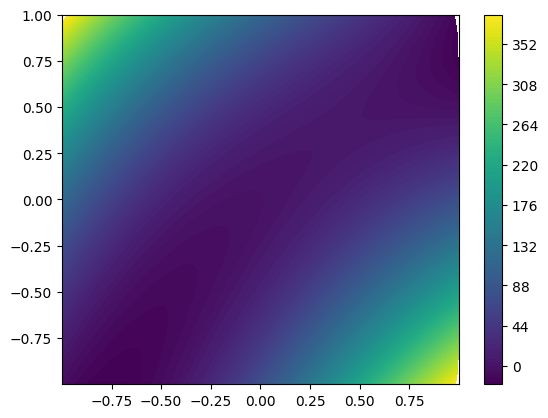

In [11]:
X = dftrain[dftrain['x3'] == 0][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
y = dftrain[dftrain['x3'] == 0]['y']

xtrain, xval, ytrain, yval = train_test_split(X, y, test_size = 0.2, random_state = randseed)

mndeg = 1
mxdeg = 10

deg = [i for i in range(mndeg, mxdeg + 1)]
lam = [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
evals = [0 for _ in range(len(lam))]

bestdeg = -1
bestlam = -1
besteval = -1

for i, d in enumerate(deg):
    for j, l in enumerate(lam):
        model = getmodel(d, l)
        model.fit(xtrain, ytrain)
        evals[j] = (mean_squared_error(yval, model.predict(xval)))
        # print(f'lambda = {l}: ein = {mean_squared_error(ytrain, model.predict(xtrain))} eval = {evals[j]}')

    cureval = min(evals)
    curlam = lam[evals.index(cureval)]
    print(f'Order {d}: eval = {cureval} lam = {curlam}')
    
    if besteval == -1 or besteval > cureval:
        bestdeg = d
        bestlam = curlam
        besteval = cureval

print()
print(f'Best (eval = {besteval}): deg = {bestdeg} lam = {bestlam}')

model = getmodel(bestdeg, bestlam)
model.fit(xtrain, ytrain)

plt.tricontourf(xval[:, 0], xval[:, 1], yval, levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

plt.tricontourf(xval[:, 0], xval[:, 1], model.predict(xval), levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

Order 1: eval = 253444.00366967634 lam = 1000.0
Order 2: eval = 246393.85708107514 lam = 0
Order 3: eval = 246373.64751582302 lam = 0
Order 4: eval = 246345.8181473343 lam = 0
Order 5: eval = 246300.94665294263 lam = 0
Order 6: eval = 246315.8640939104 lam = 10.0
Order 7: eval = 246334.8443790546 lam = 10.0
Order 8: eval = 246361.35137428678 lam = 100.0
Order 9: eval = 246368.09261803958 lam = 100.0
Order 10: eval = 246378.47429533763 lam = 100.0

Best (eval = 246300.94665294263): deg = 5 lam = 0


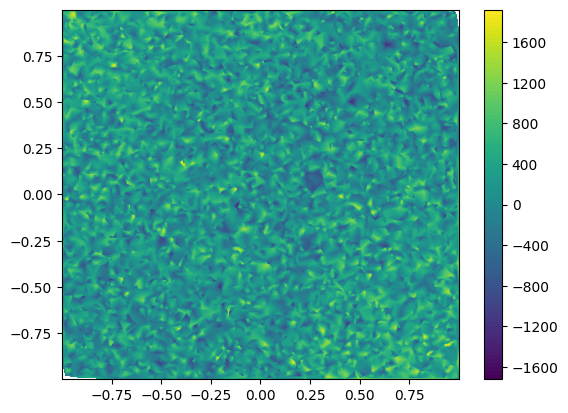

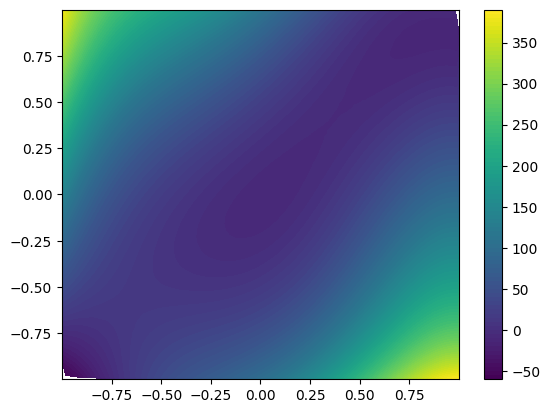

In [12]:
X = dftrain[dftrain['x3'] == 1][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
X[:, 1] -= X[:, 0]
y = dftrain[dftrain['x3'] == 1]['y']

xtrain, xval, ytrain, yval = train_test_split(X, y, test_size = 0.2, random_state = randseed)

mndeg = 1
mxdeg = 10

deg = [i for i in range(mndeg, mxdeg + 1)]
lam = [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
evals = [0 for _ in range(len(lam))]

bestdeg = -1
bestlam = -1
besteval = -1

for i, d in enumerate(deg):
    for j, l in enumerate(lam):
        model = getmodel(d, l)
        model.fit(xtrain, ytrain)
        evals[j] = (mean_squared_error(yval, model.predict(xval)))
        # print(f'lambda = {l}: ein = {mean_squared_error(ytrain, model.predict(xtrain))} eval = {evals[j]}')

    cureval = min(evals)
    curlam = lam[evals.index(cureval)]
    print(f'Order {d}: eval = {cureval} lam = {curlam}')
    
    if besteval == -1 or besteval > cureval:
        bestdeg = d
        bestlam = curlam
        besteval = cureval

print()
print(f'Best (eval = {besteval}): deg = {bestdeg} lam = {bestlam}')

model = getmodel(bestdeg, bestlam)
model.fit(xtrain, ytrain)

plt.tricontourf(xval[:, 0], xval[:, 1], yval, levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

plt.tricontourf(xval[:, 0], xval[:, 1], model.predict(xval), levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

# Linear regression with 80-20 validation set (in hindsight: why??) and 10-fold CV

Best model: {'polynomialfeatures__degree': 1, 'ridge__alpha': 100000.0}
Ein: 254789.58782227468
Eval: 253795.16586132545


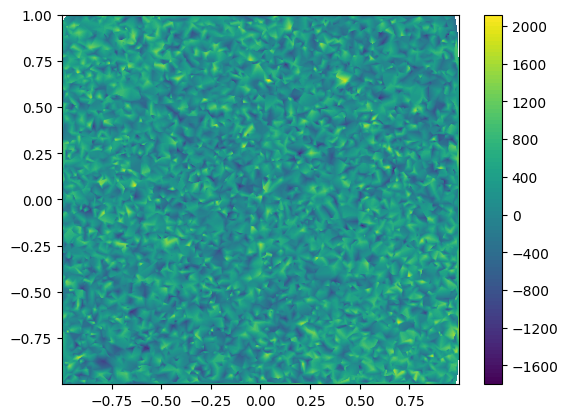

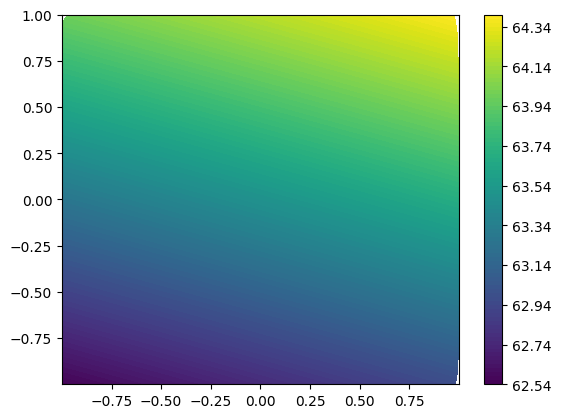

In [24]:
X = dftrain[dftrain['x3'] == 0][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
y = dftrain[dftrain['x3'] == 0]['y']

xtrain, xval, ytrain, yval = train_test_split(X, y, test_size = 0.2, random_state = randseed)

pipeline = make_pipeline(
    PolynomialFeatures(include_bias = False),
    Ridge()
)

param_grid = {
    'polynomialfeatures__degree': [i for i in range(1, 2)],
    'ridge__alpha': [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
}

grid = GridSearchCV(pipeline, param_grid, cv = 10, scoring = 'neg_mean_squared_error')
grid.fit(xtrain, ytrain)

finalcase0model = grid.best_estimator_

print(f'Best model: {grid.best_params_}')
print(f'Ein: {-grid.best_score_}')
print(f'Eval: {mean_squared_error(yval, finalcase0model.predict(xval))}')

plt.tricontourf(xval[:, 0], xval[:, 1], yval, levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

plt.tricontourf(xval[:, 0], xval[:, 1], finalcase0model.predict(xval), levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

Best model: {'polynomialfeatures__degree': 2, 'ridge__alpha': 10.0}
Ein: 247887.78511657123
Eval: 246396.2753729686


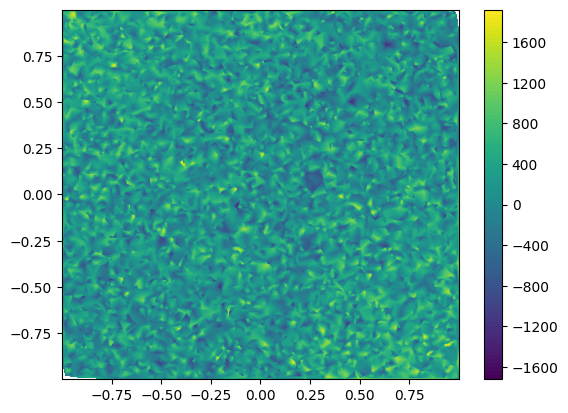

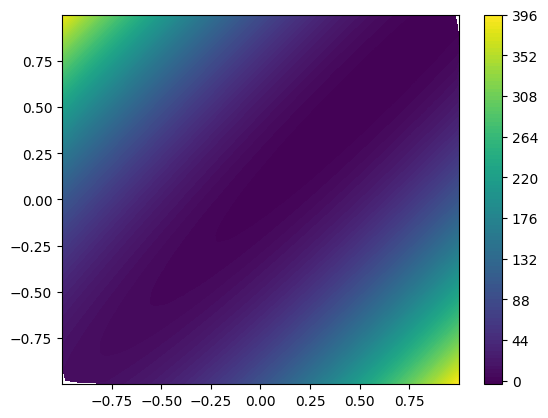

In [ ]:
X = dftrain[dftrain['x3'] == 1][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
X[:, 1] -= X[:, 0]
y = dftrain[dftrain['x3'] == 1]['y']

xtrain, xval, ytrain, yval = train_test_split(X, y, test_size = 0.2, random_state = randseed)

pipeline = make_pipeline(
    PolynomialFeatures(include_bias = False),
    Ridge()
)

param_grid = {
    'polynomialfeatures__degree': [i for i in range(1, 11)],
    'ridge__alpha': [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
}

grid = GridSearchCV(pipeline, param_grid, cv = 10, scoring = 'neg_mean_squared_error')
grid.fit(xtrain, ytrain)

finalcase1model = grid.best_estimator_

print(f'Best model: {grid.best_params_}')
print(f'Ein: {-grid.best_score_}')
print(f'Eval: {mean_squared_error(yval, model.predict(xval))}')

plt.tricontourf(xval[:, 0], xval[:, 1], yval, levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

plt.tricontourf(xval[:, 0], xval[:, 1], model.predict(xval), levels = 100, cmap = 'viridis')
plt.colorbar()
plt.show()

# Linear regression with repeated 10-fold CV

In [6]:
X = dftrain[dftrain['x3'] == 0][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
y = dftrain[dftrain['x3'] == 0]['y']

pipeline = make_pipeline(
    PolynomialFeatures(include_bias = False),
    Ridge()
)

param_grid = {
    'polynomialfeatures__degree': [i for i in range(1, 11)],
    'ridge__alpha': [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
}

cv = RepeatedKFold(n_splits = 10, n_repeats = 10, random_state = randseed)

grid = GridSearchCV(pipeline, param_grid, cv = cv, scoring = 'neg_mean_squared_error')
grid.fit(X, y)

finalcase0model = grid.best_estimator_

print(f'Best model: {grid.best_params_}')
print(f'E avg: {-grid.best_score_}')

# plt.tricontourf(X[:, 0], X[:, 1], y, levels = 100, cmap = 'viridis')
# plt.colorbar()
# plt.show()

# plt.tricontourf(X[:, 0], X[:, 1], model.predict(X), levels = 100, cmap = 'viridis')
# plt.colorbar()
# plt.show()

Best model: {'polynomialfeatures__degree': 3, 'ridge__alpha': 100.0}
E avg: 248328.77943268834


In [ ]:
X = dftrain[dftrain['x3'] == 0][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
X[:, 1] -= X[:, 0]
y = dftrain[dftrain['x3'] == 0]['y']

pipeline = make_pipeline(
    PolynomialFeatures(include_bias = False),
    Ridge()
)

param_grid = {
    'polynomialfeatures__degree': [i for i in range(1, 11)],
    'ridge__alpha': [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
}

cv = RepeatedKFold(n_splits = 10, n_repeats = 10, random_state = randseed)

grid = GridSearchCV(pipeline, param_grid, cv = cv, scoring = 'neg_mean_squared_error')
grid.fit(X, y)

finalcase1model = grid.best_estimator_

print(f'Best model: {grid.best_params_}')
print(f'E avg: {-grid.best_score_}')

# plt.tricontourf(X[:, 0], X[:, 1], y, levels = 100, cmap = 'viridis')
# plt.colorbar()
# plt.show()

# plt.tricontourf(X[:, 0], X[:, 1], model.predict(X), levels = 100, cmap = 'viridis')
# plt.colorbar()
# plt.show()

Best model: {'polynomialfeatures__degree': 2, 'ridge__alpha': 100.0}
E avg: 248368.0104372746


# Linear regression with t test and 10-fold cross validation

In [ ]:
def ttest(deg, lam, X, y):
    poly = PolynomialFeatures(deg, include_bias = True)
    poly.fit(X)
    Z = poly.fit_transform(X)

    model = Ridge(alpha = lam, fit_intercept = False)
    model.fit(Z, y)
    

In [ ]:
X = dftrain[dftrain['x3'] == 0][['x1', 'x2']].to_numpy()
X[:, 0] /= 10
X[:, 1] /= .003
y = dftrain[dftrain['x3'] == 0]['y']

cur = ttest(3, 100, X, y)

# pipeline = make_pipeline(
#     PolynomialFeatures(include_bias = False),
#     Ridge()
# )

# param_grid = {
#     'polynomialfeatures__degree': [i for i in range(1, 11)],
#     'ridge__alpha': [0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5]
# }

# cv = RepeatedKFold(n_splits = 10, n_repeats = 10, random_state = randseed)

# grid = GridSearchCV(pipeline, param_grid, cv = cv, scoring = 'neg_mean_squared_error')
# grid.fit(X, y)

# finalcase0model = grid.best_estimator_

# print(f'Best model: {grid.best_params_}')
# print(f'E avg: {-grid.best_score_}')

(49927, 9)


# Using "finalcase0model" and "finalcase1model" to get $y_{out}$

In [8]:
dftest = pd.read_csv('./test_proj/check_data.csv')

In [9]:
yout = np.empty(len(dftest))
yout[:] = np.nan

X0 = dftest[dftest['x3'] == 0][['x1', 'x2']].to_numpy()
X1 = dftest[dftest['x3'] == 1][['x1', 'x2']].to_numpy()

X0[:, 0] /= 10
X0[:, 1] /= .003

X1[:, 0] /= 10
X1[:, 1] /= .003
X1[:, 1] -= X1[:, 0]

yout[dftest['x3'] == 0] = finalcase0model.predict(X0)
yout[dftest['x3'] == 1] = finalcase0model.predict(X1)

dfout = dftest.copy()
dfout['y'] = yout
dfout.to_csv('check_pred.csv', index = False)
print(dfout)

            x1        x2  x3           y
0     4.397037  0.001943   0   11.884328
1    -2.783894  0.002305   0  105.661778
2    -0.528724  0.002909   0  113.240194
3     4.321660  0.003909   1   31.827929
4    -2.640812 -0.001368   1   -3.177872
...        ...       ...  ..         ...
9995  3.206236  0.000151   1   41.936714
9996 -3.374039  0.001151   0   45.816179
9997  7.975181  0.000750   0   23.270877
9998  8.894660  0.001920   0  -10.723797
9999 -2.464840 -0.003728   1   16.708522

[10000 rows x 4 columns]
